In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, 
                             confusion_matrix, roc_auc_score,
                             roc_curve, classification_report)
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading Data
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print("Data loaded!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Data loaded!
X_train shape: (8278, 33)
X_test shape: (1409, 33)


In [3]:
# Defining Models 
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'XGBoost':             XGBClassifier(random_state=42, 
                                         eval_metric='logloss',
                                         verbosity=0)
}


In [4]:
#  Training & Evaluating All Models
results = []

for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)
    
    results.append({
        'Model':     name,
        'Accuracy':  round(acc, 4),
        'Precision': round(prec, 4),
        'Recall':    round(rec, 4),
        'F1 Score':  round(f1, 4),
        'ROC AUC':   round(auc, 4)
    })
    
    print(f"   Accuracy:  {acc:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall:    {rec:.4f}")
    print(f"   F1 Score:  {f1:.4f}")
    print(f"   ROC AUC:   {auc:.4f}")


🔄 Training Logistic Regression...
   Accuracy:  0.7402
   Precision: 0.5080
   Recall:    0.6791
   F1 Score:  0.5812
   ROC AUC:   0.8269

🔄 Training Random Forest...
   Accuracy:  0.7622
   Precision: 0.5455
   Recall:    0.6257
   F1 Score:  0.5828
   ROC AUC:   0.8203

🔄 Training Gradient Boosting...
   Accuracy:  0.7459
   Precision: 0.5145
   Recall:    0.7567
   F1 Score:  0.6126
   ROC AUC:   0.8399

🔄 Training XGBoost...
   Accuracy:  0.7601
   Precision: 0.5398
   Recall:    0.6524
   F1 Score:  0.5908
   ROC AUC:   0.8111


In [5]:
# Results Summary
results_df = pd.DataFrame(results).sort_values('ROC AUC', ascending=False)
print("\n Model Comparison:")
print(results_df.to_string(index=False))

# Saving Best Model 
best_model_name = results_df.iloc[0]['Model']
best_model      = models[best_model_name]

joblib.dump(best_model, '../models/best_model.pkl')
results_df.to_csv('../data/model_results.csv', index=False)
print(f"\n Best model saved: {best_model_name}")


 Model Comparison:
              Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
  Gradient Boosting    0.7459     0.5145  0.7567    0.6126   0.8399
Logistic Regression    0.7402     0.5080  0.6791    0.5812   0.8269
      Random Forest    0.7622     0.5455  0.6257    0.5828   0.8203
            XGBoost    0.7601     0.5398  0.6524    0.5908   0.8111

 Best model saved: Gradient Boosting


 Confusion matrix saved!


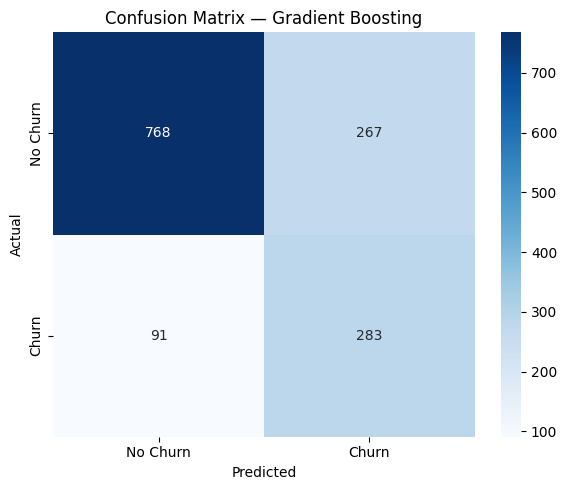

In [6]:
# Confusion Matrix (Best Model) 
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png')
print(" Confusion matrix saved!")

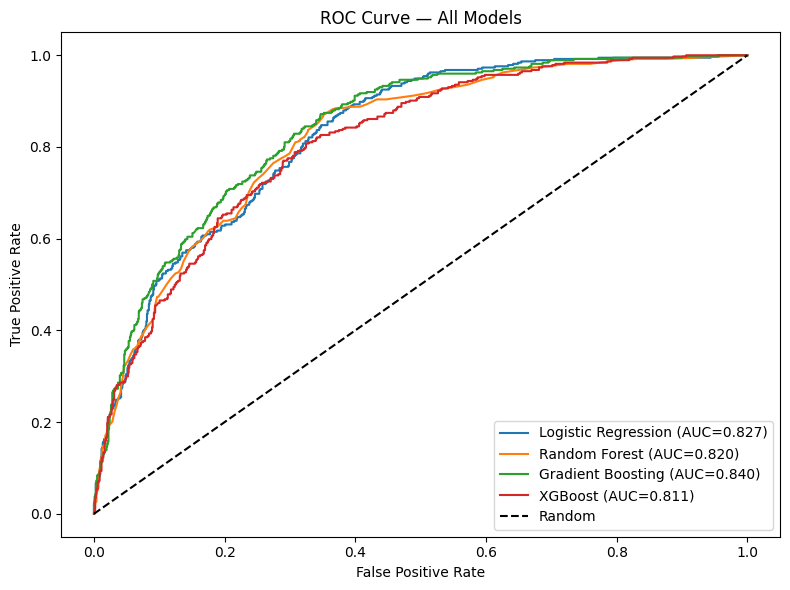

 ROC curve saved!


In [7]:
# ROC Curve (All Models)
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend()
plt.tight_layout()
plt.savefig('../data/roc_curve.png')
plt.show()
print(" ROC curve saved!")



In [8]:
#The Classification Report (Best Model)
print(f"\n Classification Report — {best_model_name}:")
print(classification_report(y_test, y_pred_best, 
                            target_names=['No Churn', 'Churn']))


 Classification Report — Gradient Boosting:
              precision    recall  f1-score   support

    No Churn       0.89      0.74      0.81      1035
       Churn       0.51      0.76      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



In [9]:
# Saving training column names
joblib.dump(
    X_train.columns.tolist(),
    '../models/model_columns.pkl'
)

print(" model_columns.pkl saved")

 model_columns.pkl saved
